# Data

In [4]:
from torchvision import datasets
import os
import kagglehub

# Download latest version
DATA_PATH = kagglehub.dataset_download("jessicali9530/stanford-dogs-dataset")
IMG_PATH = os.path.join(DATA_PATH, "images", "Images")
ANNOTATION_PATH = os.path.join(DATA_PATH, "annotations", "Annotations")

print("Path to dataset files:", DATA_PATH)

dataset = datasets.ImageFolder(root=IMG_PATH)

Path to dataset files: /home/franio/.cache/kagglehub/datasets/jessicali9530/stanford-dogs-dataset/versions/2


# Model, Images and Predictions

In [5]:
import torch
from utils.metric_functions import test_on_given_idx
from torchvision.models import resnet
from torchvision import transforms
import numpy as np


MODEL_NAME = 'resnet18_dogs_5_epochs'

net_model = resnet.resnet18()
net_model.load_state_dict(torch.load(os.path.join('models', f"{MODEL_NAME}.pth"), weights_only=True))

#transforms for prediction
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
transform = transforms.Compose([transforms.Resize((224,224)),
                                         transforms.ToTensor(),
                                         transforms.Normalize(mean, std)])

idx = np.random.choice(np.arange(start=0, stop=len(dataset)), size=6, replace=False)
preds, df = test_on_given_idx(dataset, net_model,transform, idx=idx)
df

,Idx,True_Label,Predicted_Label
0,13184,n02105412-kelpie,n02105412-kelpie
1,348,n02085936-Maltese_dog,n02098286-West_Highland_white_terrier
2,7922,n02096437-Dandie_Dinmont,n02096437-Dandie_Dinmont
3,5879,n02093859-Kerry_blue_terrier,n02093859-Kerry_blue_terrier
4,19122,n02112706-Brabancon_griffon,n02112706-Brabancon_griffon
5,17277,n02110806-basenji,n02110806-basenji


## Images

array([13184,   348,  7922,  5879, 19122, 17277])

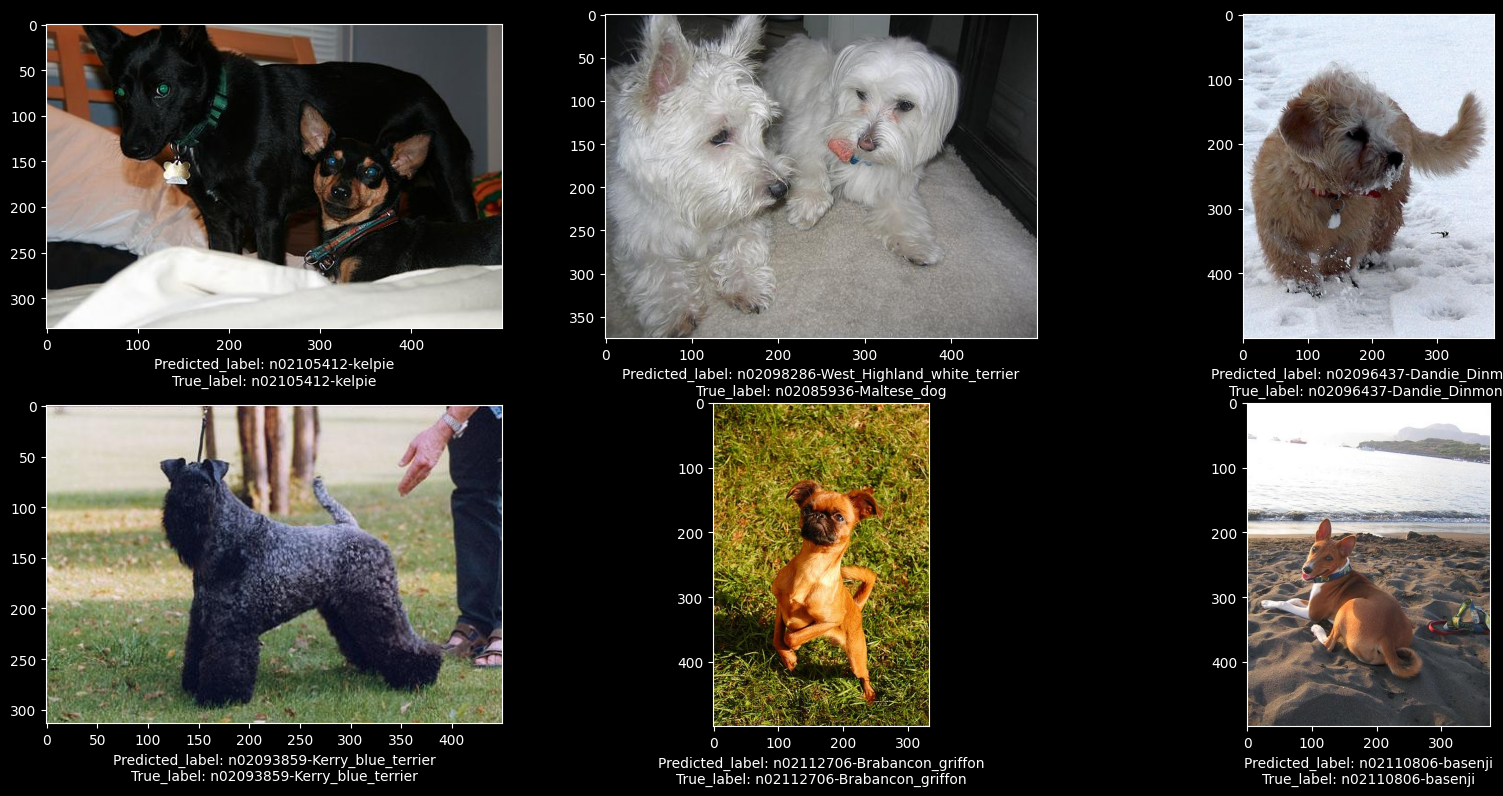

In [6]:
from utils.plot import plot_idx_labeled

plot_idx_labeled(idx,preds,dataset)


# Explaining with SHAP
SHAP is a library for explaining models via shapley values.

 89%|████████▉ | 4442/4998 [00:04<00:00, 811.06it/s]  
PartitionExplainer explainer: 7it [01:10, 11.73s/it]                       


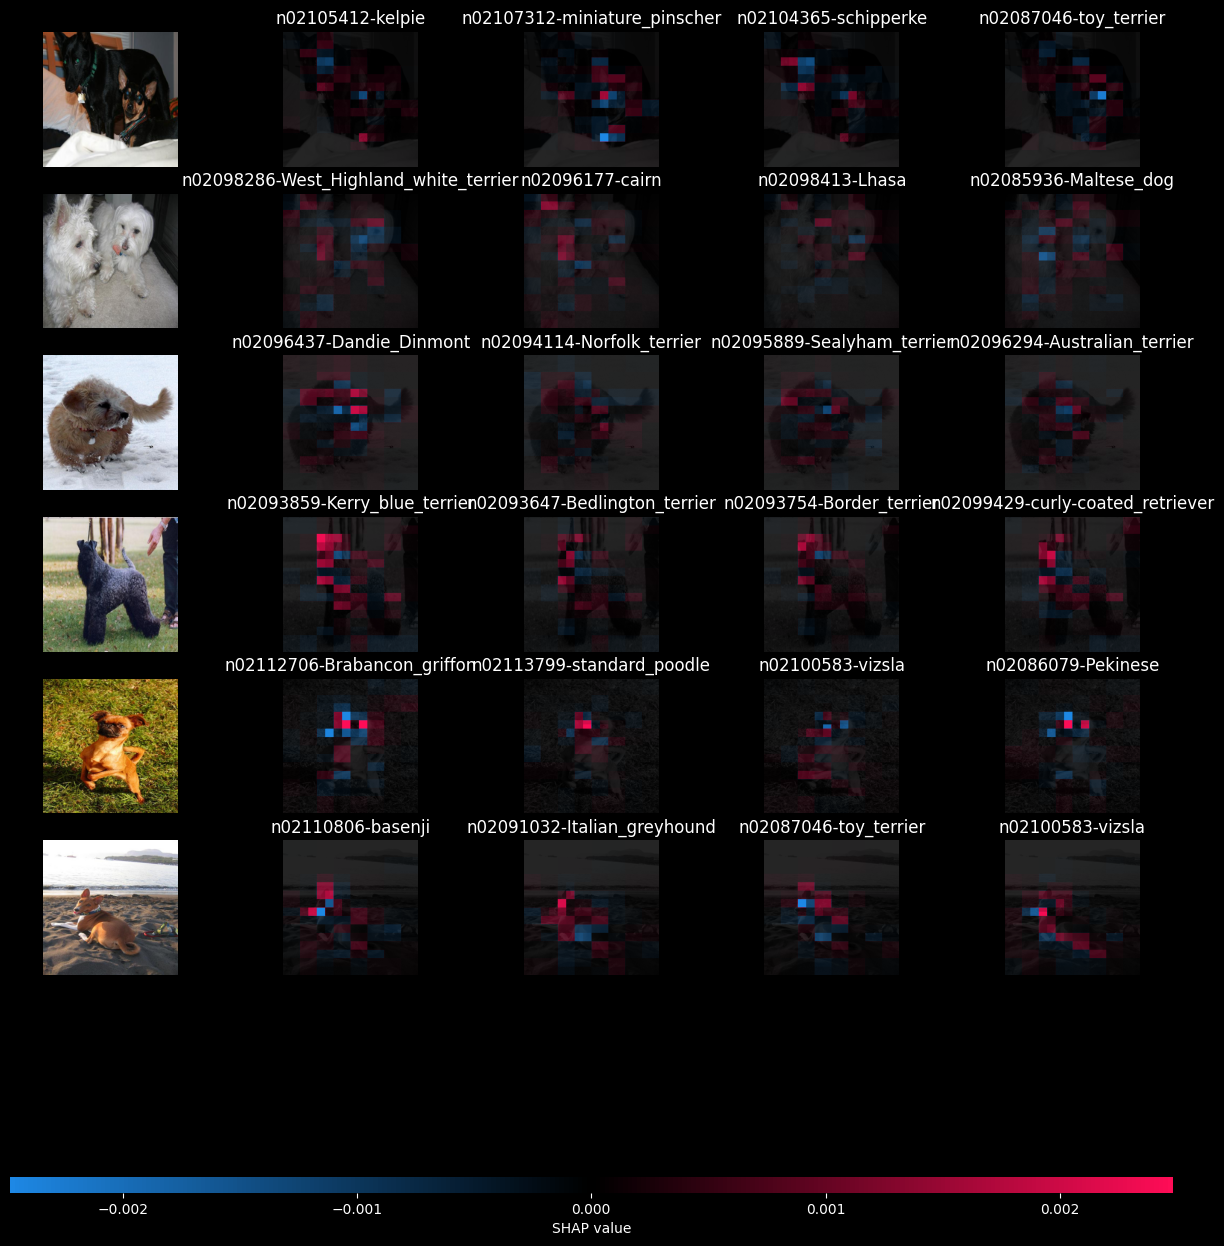

In [22]:
import torchvision
from torchvision import transforms
import PIL
import shap

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize(mean, std)])



def predict(batch: np.ndarray) -> torch.Tensor:
    global net_model, device, transform

    net_model.eval()
    list_of_tensors = [transform(img) for img in batch]
    img_tensor = torch.stack(list_of_tensors).to(device)
    output = net_model(img_tensor)
    pred = output.detach().cpu()
    return pred




list_of_np_arrays = [np.array(dataset[i][0].resize((224,224))) for i in idx]
targets = np.array([dataset[i][1] for i in idx])
topk = 4
batch_size = 50
n_evals = 5000
class_names = dataset.classes


list_of_np_arrays = [np.array(dataset[i][0].resize((224,224))) for i in idx]
sample = np.stack(list_of_np_arrays)

# define a masker that is used to mask out partitions of the input image.
masker_blur = shap.maskers.Image("blur(2,2)", sample[0].shape)

# create an explainer with model and image masker
explainer = shap.Explainer(predict, masker_blur, output_names=class_names)

# feed only one image
# here we explain two images using 100 evaluations of the underlying model to estimate the SHAP values
shap_values = explainer(
    sample,
    max_evals=n_evals,
    batch_size=batch_size,
    outputs=shap.Explanation.argsort.flip[:topk],
)

shap_values.values = [val for val in np.moveaxis(shap_values.values, -1, 0)]
# (shap_values.data.shape, shap_values.values[0].shape)

shap.image_plot(
    shap_values=shap_values.values,
    pixel_values=shap_values.data,
    labels=shap_values.output_names,
)